# EDA (탐색적 데이터 분석)

## 1. 환경 설정 및 데이터 로드

In [2]:
import os, sys

try:
    import google.colab
    if not os.path.exists("/content/project/setup.py"):
        os.system("pip install -q gdown")
        os.system("gdown --id 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip")
        os.system("unzip -qo /content/code.zip -d /content/project")
        os.makedirs("/content/project/0_data", exist_ok=True)
        os.system("gdown --id 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip")
        os.system("unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data")
        os.remove("/content/project/0_data/dataset.zip")
    if not os.path.exists("/content/project/1_eda/modules/__init__.py"):
        os.makedirs("/content/project/1_eda/modules", exist_ok=True)
        os.system("gdown --id 1RgiR3H7hC5viu8nRGBLTUl8HZGH3bgG4 -O /content/project/1_eda/modules.zip")
        os.system("unzip -qo /content/project/1_eda/modules.zip -d /content/project/1_eda/modules")
        os.remove("/content/project/1_eda/modules.zip")
    sys.path.insert(0, "/content/project")
    sys.path.insert(0, "/content/project/1_eda")
    %run /content/project/setup.py
except ImportError:
    %run ../setup.py

# ─── 이 노트북에서 사용하는 import ───
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from utils.config import PROJECT_ROOT, META_COLS
from utils.data import load_all, get_feat_cols, split_xs

# 데이터 로드
xs, ys = load_all()
feat_cols = get_feat_cols(xs)
xs_dict = split_xs(xs)

ys_all = ys["all"]
ys_train = ys["train"]

print()
print(f"Meta columns: {META_COLS}")
print(f"Feature columns: X0 ~ X{len(feat_cols)-1} ({len(feat_cols)}개)")

setup 완료
Xs: (174980, 1091)  |  Ys: train=26,247, val=8,749, test=8,749

Meta columns: ['ufs_serial', 'run_wf_xy', 'position', 'split']
Feature columns: X0 ~ X1086 (1087개)


## 모듈 import

In [3]:
# EDA 분석 모듈 import
# 각 모듈은 modules/ 폴더에 있음. 코드 디테일은 해당 .py 파일 참고
# alias 접두사로 어느 모듈 함수인지 구분 가능
import os
for _p in ['.', os.path.join(PROJECT_ROOT, '1_eda')]:
    if os.path.isdir(os.path.join(_p, 'modules')) and _p not in sys.path:
        sys.path.insert(0, _p)

from modules import eda_overview as ov          # 데이터 구조, Target 분석
from modules import eda_feature_quality as fq   # 결측치, 분포, 분산/중복
from modules import eda_relationships as rel    # Feature-Target 상관관계, 다중공선성
from modules import eda_outlier_scale as out    # 이상치, 스케일, EDA 요약
from modules import eda_wafer_map as wm         # Wafer Map 불량 시각화

## 2. 데이터 구조 확인
- Xs: die-level wafer test data (die 단위 행)
- Ys: unit-level health data (unit 단위 행)
- 하나의 unit(ufs_serial)에 여러 die(run_wf_xy)가 매핑됨
- position: unit 내 die의 위치

In [4]:
# Xs 데이터 기본 정보: shape, dtypes, 메타 컬럼 샘플, feature 기초통계
ov.describe_xs(xs, feat_cols)

shape: (174980, 1091)

dtypes:
float64    1087
object        3
int64         1
Name: count, dtype: int64

메타 컬럼 샘플:
  ufs_serial         run_wf_xy  position       split
0     S00000  0000000_25_24_25         1       train
1     S00001  0000000_10_41_30         1        test
2     S00002   0000000_8_37_24         1       train
3     S00003  0000000_13_34_27         1       train
4     S00004  0000000_10_22_15         1       train
5     S00005  0000000_10_28_18         1  validation
6     S00006  0000000_11_52_14         1  validation
7     S00007   0000000_5_43_12         1  validation
8     S00008   0000000_6_26_14         1  validation
9     S00009   0000000_7_41_19         1       train

Feature 통계 (일부):
               X0          X1          X2          X3          X4          X5  \
count  172701.000  172854.000  172875.000  172964.000  174573.000  174573.000   
mean        0.301       0.313       0.305       0.323       0.999       1.199   
std         0.432       0.428       0.43

count    43745.0
mean         4.0
std          0.0
min          4.0
25%          4.0
50%          4.0
75%          4.0
max          4.0
dtype: float64

고유 unit 수: 43,745
고유 die 수:  174,980


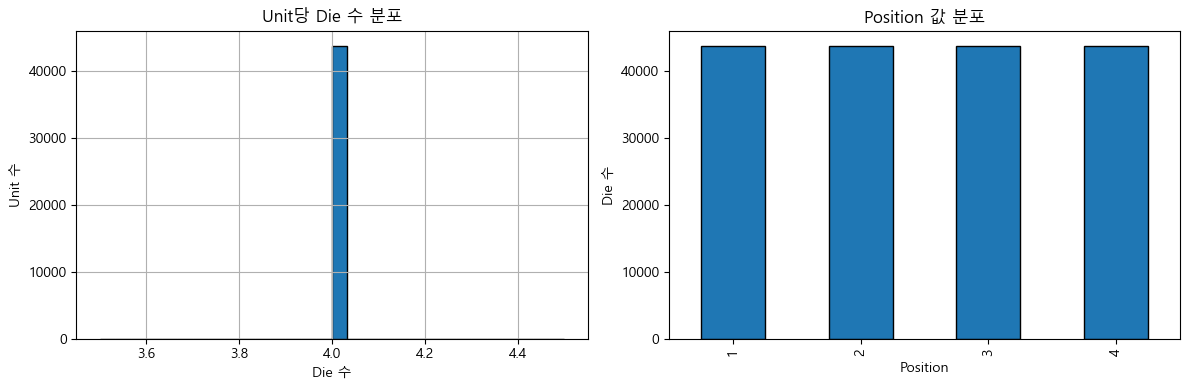

In [5]:
# unit(ufs_serial) 하나당 die가 몇 개인지 분포 확인
# + position(1~4) 값이 균등하게 분포하는지 확인
ov.plot_dies_per_unit(xs)

In [6]:
# train / validation / test split 비율 확인
# Xs는 die 단위, Ys는 unit 단위이므로 각각 출력
ov.print_split_ratio(xs, ys_all)

Xs (die level)
split
train         104988
test           34996
validation     34996
Name: count, dtype: int64
split
train         60.0
test          20.0
validation    20.0
Name: count, dtype: float64

Ys (unit level)
split
train         26247
validation     8749
test           8749
Name: count, dtype: int64
split
train         60.0
validation    20.0
test          20.0
Name: count, dtype: float64


## 3. Target 변수 (health) 분석
- 종속변수는 unit별 고객 Field Health Data (비율, 비식별화)
- Zero-inflated 분포: Y=0이 약 70.8%, Y>0이 약 29.2%
- 평가 지표: RMSE

count    43745.000000
mean         0.002532
std          0.007908
min          0.000000
25%          0.000000
50%          0.000000
75%          0.002277
max          1.000000
Name: health, dtype: float64

Y = 0 비율: 70.8%
Y > 0 비율: 29.2%


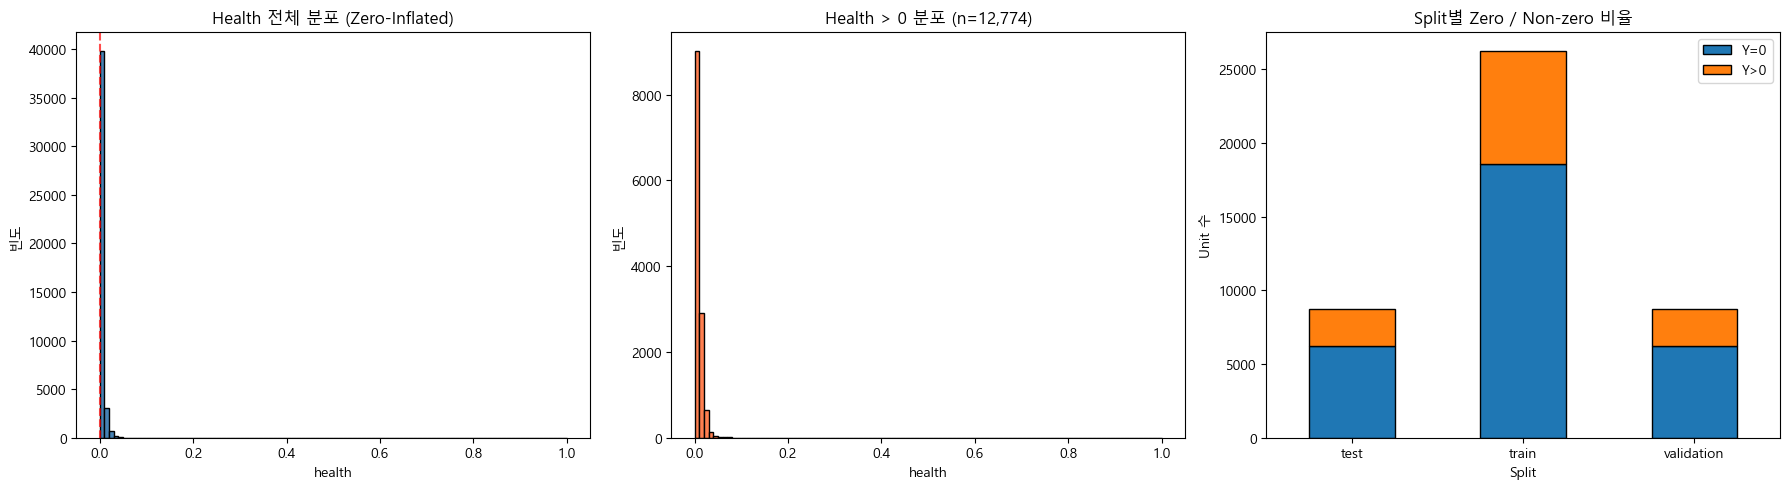

In [7]:
# Target(health) 분포 시각화
# 1) 전체 분포 (zero-inflated 확인)
# 2) Y>0인 것만 따로 분포
# 3) split별 zero/non-zero 비율 비교
ov.plot_target_distribution(ys_all)

## 4. 결측치 분석

전체 feature 수: 1087
결측 있는 feature 수: 1087
결측 없는 feature 수: 0

결측 비율 상위 20개:
       missing_count  missing_pct
X729          174128        99.51
X1051         165423        94.54
X517          161125        92.08
X597          160797        91.89
X710          158481        90.57
X1055         156758        89.59
X657          156758        89.59
X1052         155220        88.71
X593          130201        74.41
X695          130201        74.41
X696          130201        74.41
X697          130201        74.41
X698          130201        74.41
X1053         120890        69.09
X656          120890        69.09
X1054         102036        58.31
X1050         101130        57.80
X728           45190        25.83
X727           45190        25.83
X587           45186        25.82


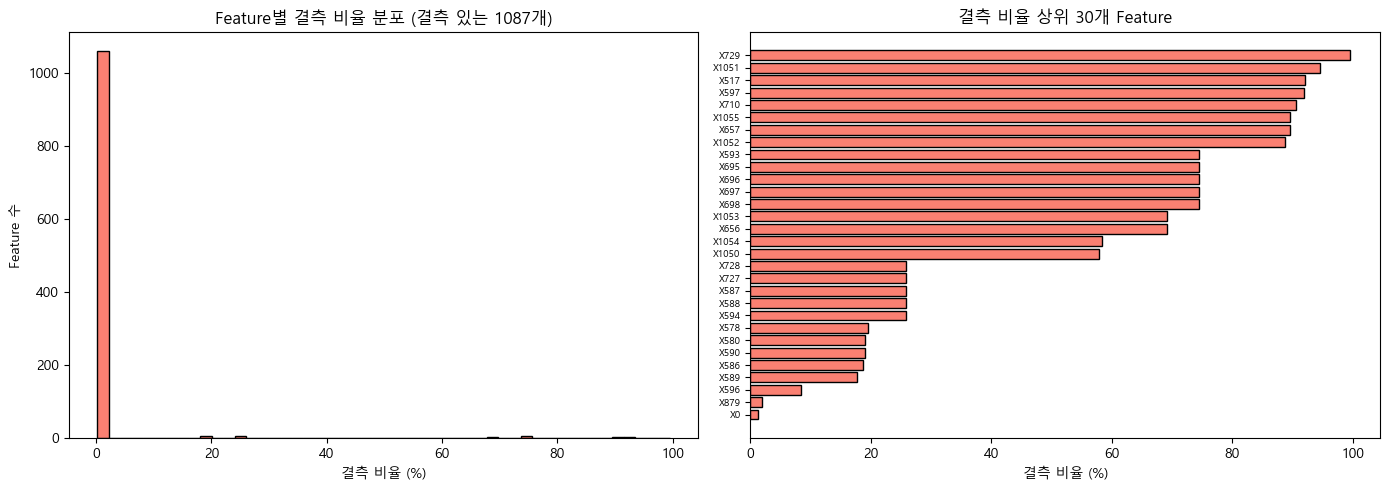

In [8]:
# feature별 결측률 분석
# 결측 있는 feature 수, 상위 20개 출력 + 결측률 분포/상위 30개 시각화
# missing_df: 결측 있는 feature의 결측수/결측률 DataFrame (이후 요약에서 사용)
missing_df = fq.analyze_missing(xs, feat_cols)

## 5. Feature 분포 분석
- X0~X1086: 연속형 + 이산형 혼합
- 연속형 / 이산형 구분 후 분포 확인

연속형 feature: 696개
이산형 feature: 391개 (고유값 수 20)


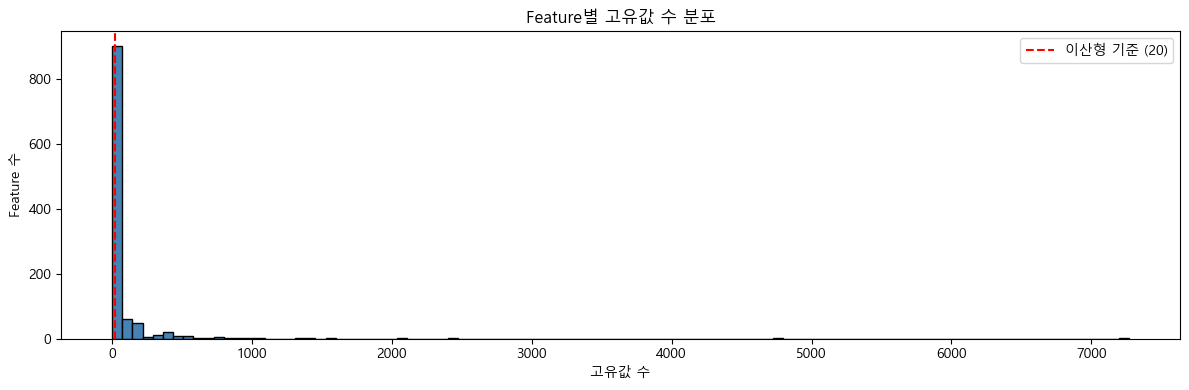


이산형 Feature 고유값 수:
X349      1
X1035     1
X1034     1
X1028     1
X1027     1
         ..
X415     20
X996     20
X286     20
X165     20
X1081    20
Length: 391, dtype: int64


In [9]:
# 연속형 / 이산형 feature 자동 분류 (고유값 20개 이하 -> 이산형)
# + feature별 고유값 수 분포 히스토그램
# 반환값은 이후 시각화와 요약에서 사용
continuous_feats, discrete_feats = fq.classify_features(xs, feat_cols)

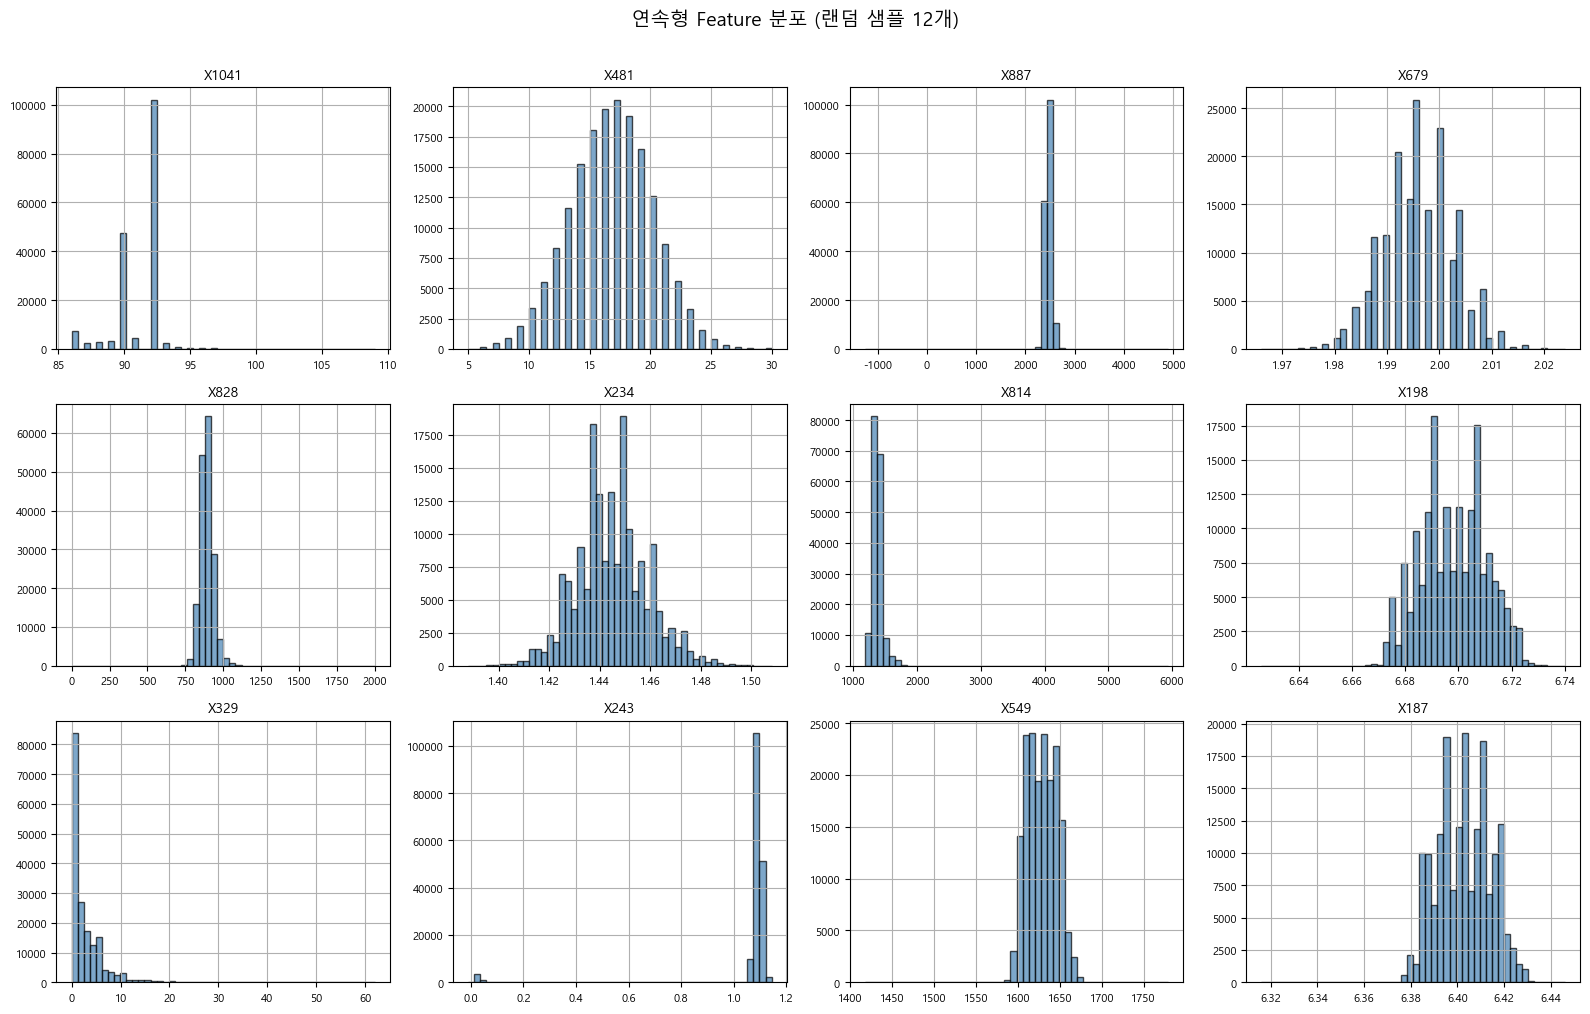

In [10]:
# 연속형 feature 중 랜덤 12개 골라서 히스토그램
# 전체 분포 경향 파악용 (스케일 차이, 편향 등)
fq.plot_continuous_dist(xs, continuous_feats)

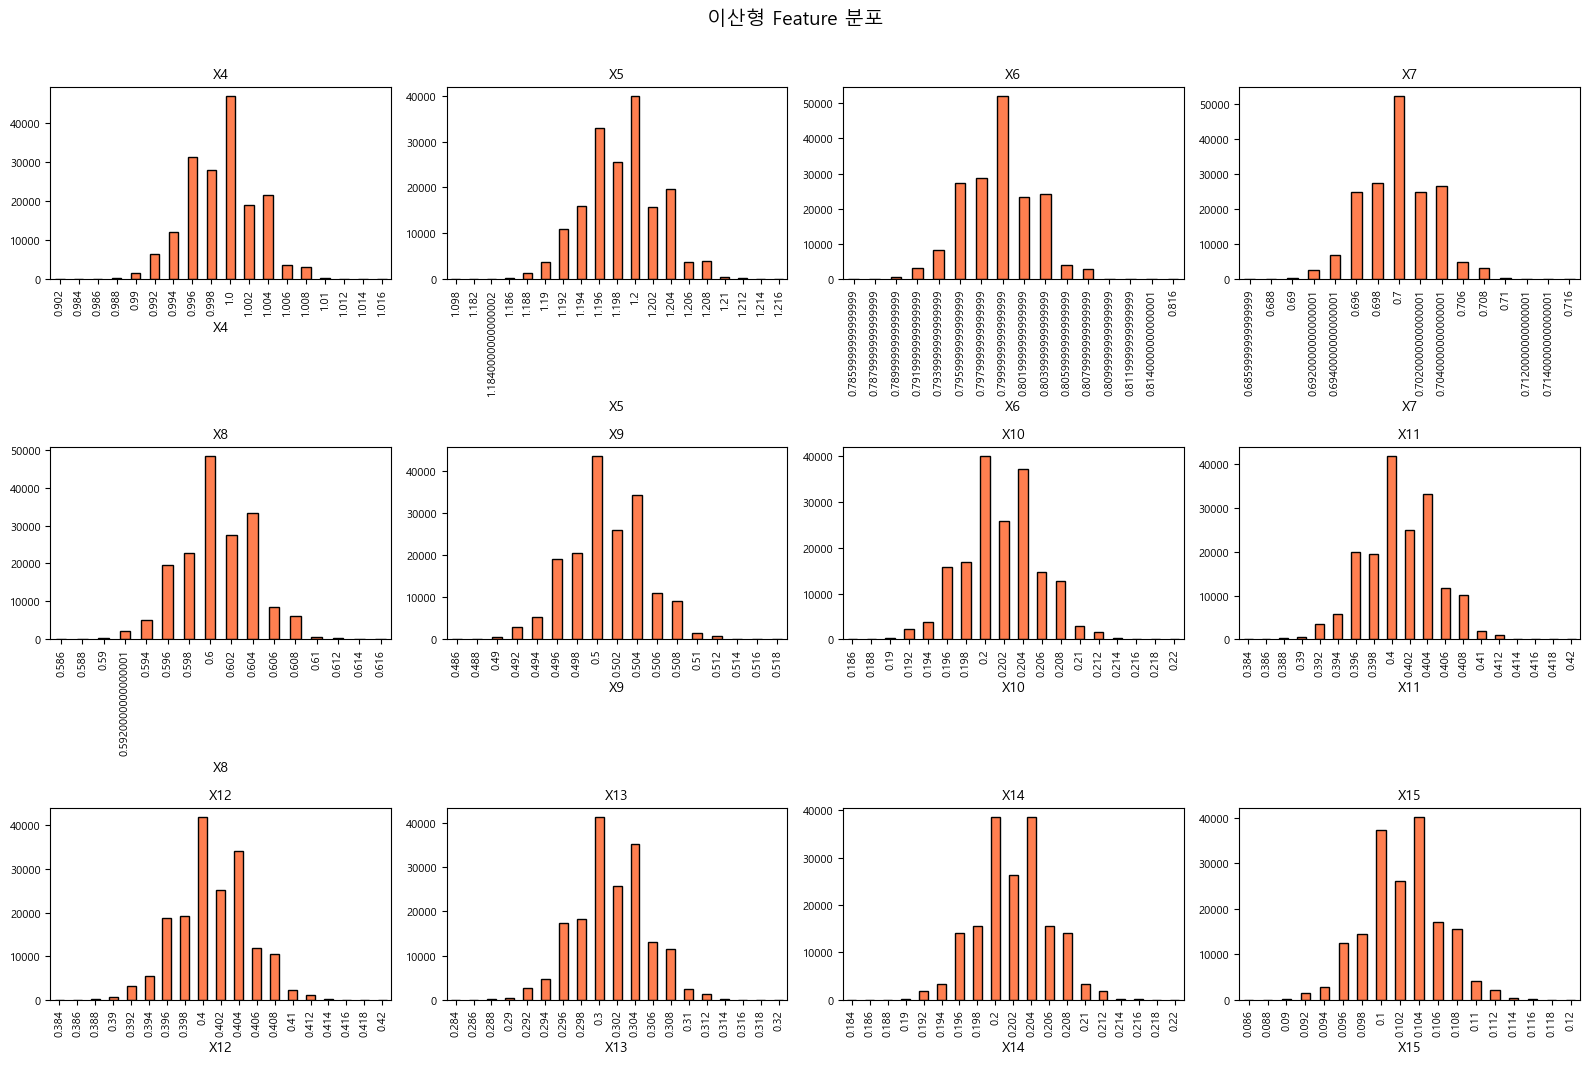

In [11]:
# 이산형 feature 최대 12개의 값 분포 (bar chart)
# 특정 값에 쏠림이 있는지, 고유값이 몇 개인지 확인
fq.plot_discrete_dist(xs, discrete_feats)

## 6. 분산 분석 및 중복/상수 Feature 탐지

상수 feature (std=0): 97개
극저분산 feature (std<1e-6): 105개

상수 features: ['X338', 'X339', 'X341', 'X343', 'X345', 'X347', 'X349', 'X350', 'X351', 'X352', 'X353', 'X360', 'X362', 'X363', 'X370', 'X371', 'X422', 'X423', 'X424', 'X437']...

중복 컬럼 탐색 (샘플 기반):
완전 중복 컬럼 쌍: 1974개
  X303 == X304
  X303 == X609
  X303 == X610
  X304 == X609
  X304 == X610
  X305 == X325
  X305 == X634
  X307 == X612
  X311 == X614
  X313 == X617
  ... 외 1964개


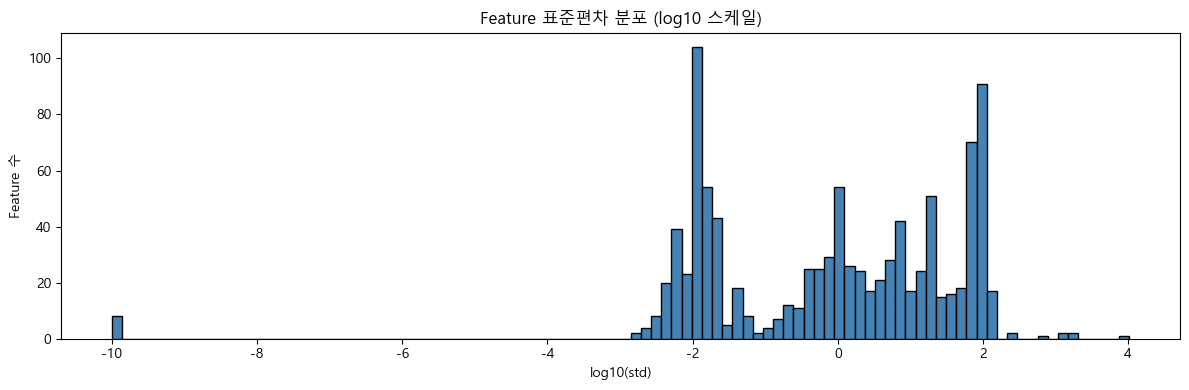

In [12]:
# 제거 대상 feature 탐지
# - 상수 feature (std=0): 정보량 없음
# - 극저분산 feature (std<1e-6): 사실상 상수
# - 완전 중복 컬럼 쌍: 샘플 5,000개 기준으로 탐색
# + feature 표준편차 분포 (log10 스케일) 시각화
const_feats, low_var_feats, dup_pairs = fq.detect_low_variance(xs, feat_cols)

## 7. Feature-Target 상관관계 분석
- die-level feature를 unit-level로 집계(평균)하여 target과 비교
- 상관계수 기반 주요 feature 탐색

In [13]:
# die -> unit 평균 집계 후 target(health)과 Pearson 상관계수 계산
# train set만 사용 (데이터 누수 방지)
# - train_merged: unit-level로 집계된 X + Y 합본 DataFrame
# - corr_with_target: 각 feature의 상관계수 (부호 포함)
# - corr_abs: 절대값 기준 내림차순 정렬
train_merged, corr_with_target, corr_abs = rel.compute_correlation(xs_dict, ys_train, feat_cols)

Train merged shape: (26247, 1089)

상관계수 상위 20개 Feature:
     X1083: -0.0372
      X769: +0.0367
      X739: +0.0362
      X881: -0.0337
     X1085: +0.0334
      X844: -0.0318
      X761: +0.0316
      X348: -0.0309
      X344: -0.0308
      X271: -0.0304
      X299: +0.0304
      X295: +0.0298
      X750: +0.0298
      X821: +0.0296
      X254: +0.0293
     X1084: -0.0290
      X744: +0.0290
      X235: +0.0289
      X257: +0.0289
      X749: +0.0287


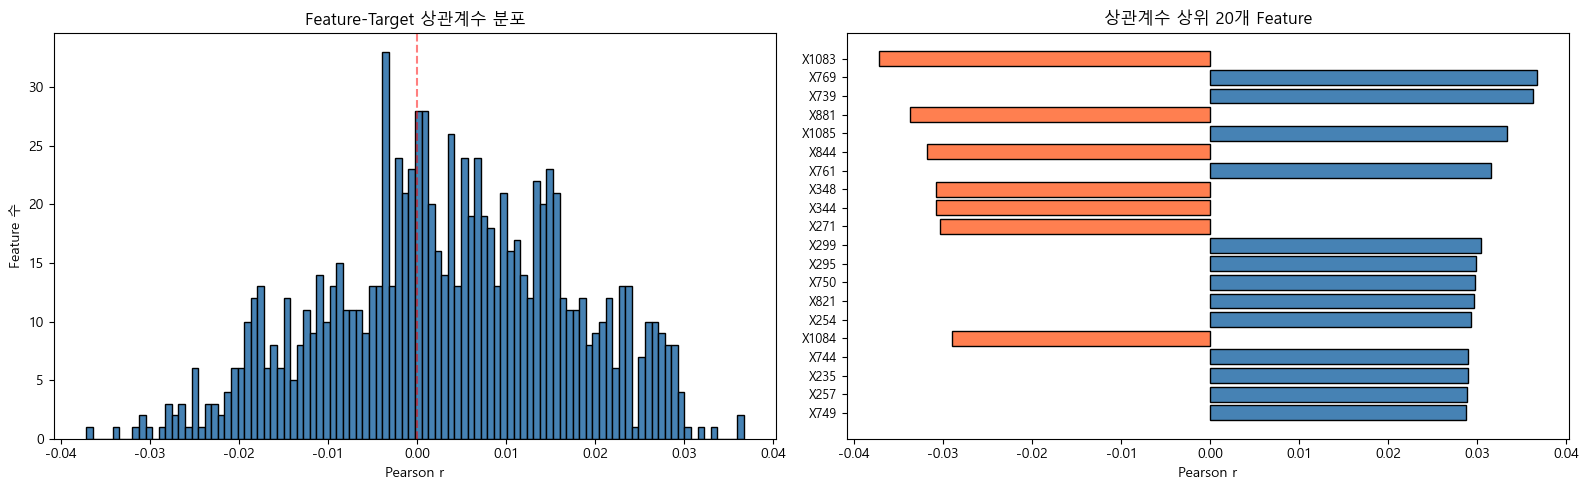

In [14]:
# 전체 상관계수 분포 히스토그램 + 상위 20개 feature bar chart
rel.plot_corr_with_target(corr_with_target, corr_abs)

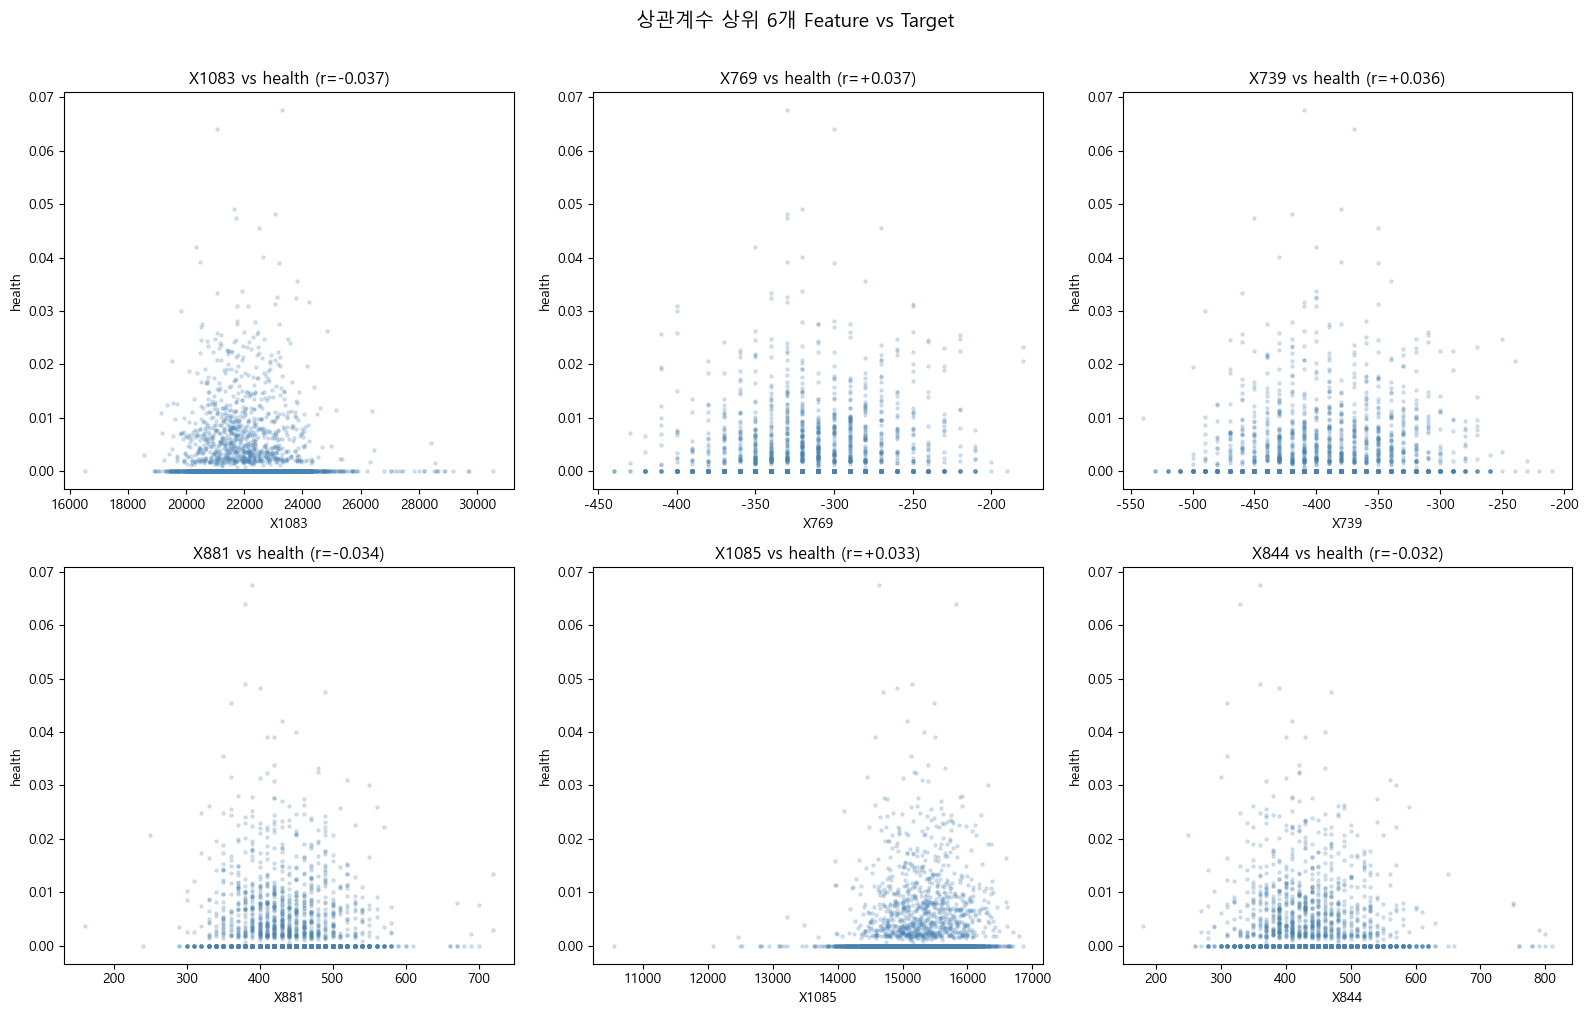

In [15]:
# 상관계수 상위 6개 feature vs health scatter plot
# 비선형 관계나 이상치 패턴 시각적으로 확인
rel.plot_top_scatter(train_merged, corr_with_target, corr_abs)

## 8. Feature 간 상관관계 (다중공선성 확인)

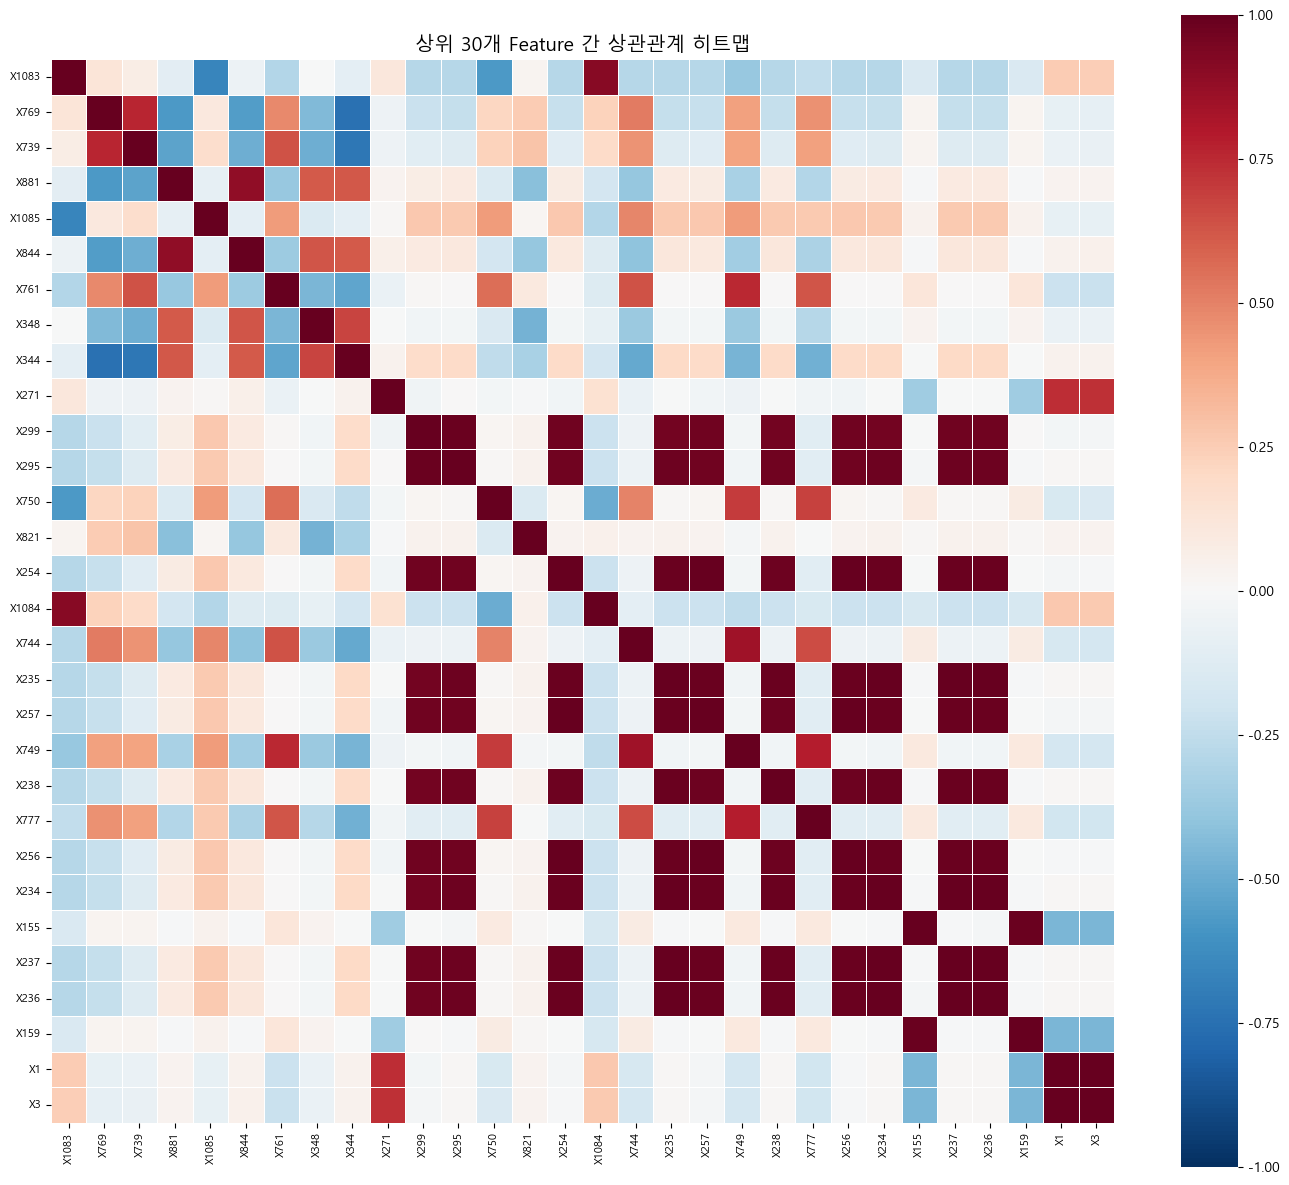

|r| > 0.95인 Feature 쌍: 47개
      X235 ↔ X234    : r=+0.9982
      X234 ↔ X236    : r=+0.9982
      X237 ↔ X236    : r=+0.9982
      X235 ↔ X236    : r=+0.9981
      X234 ↔ X237    : r=+0.9979
      X235 ↔ X237    : r=+0.9979
      X257 ↔ X256    : r=+0.9977
      X254 ↔ X256    : r=+0.9977
      X254 ↔ X257    : r=+0.9976
        X1 ↔ X3      : r=+0.9948
      X256 ↔ X237    : r=+0.9911
      X256 ↔ X236    : r=+0.9911
      X257 ↔ X237    : r=+0.9910
      X254 ↔ X236    : r=+0.9910
      X254 ↔ X234    : r=+0.9909


In [16]:
# target 상관 상위 30개 feature끼리의 상관관계 히트맵
# |r| > 0.95인 쌍 출력 -> 다중공선성 높은 feature 파악
rel.plot_feature_heatmap(train_merged, corr_abs)

## 9. 이상치(Outlier) 탐지

이상치 비율 > 5% Feature: 167개
이상치 비율 > 10% Feature: 62개

이상치 비율 상위 20개:
X393    45.66
X988    40.42
X989    36.53
X976    32.54
X720    30.85
X950    28.48
X484    27.84
X971    27.09
X492    26.87
X485    26.82
X493    26.73
X483    26.25
X496    26.07
X914    25.35
X951    24.85
X491    24.47
X924    23.00
X915    21.39
X937    20.74
X975    20.66
dtype: float64


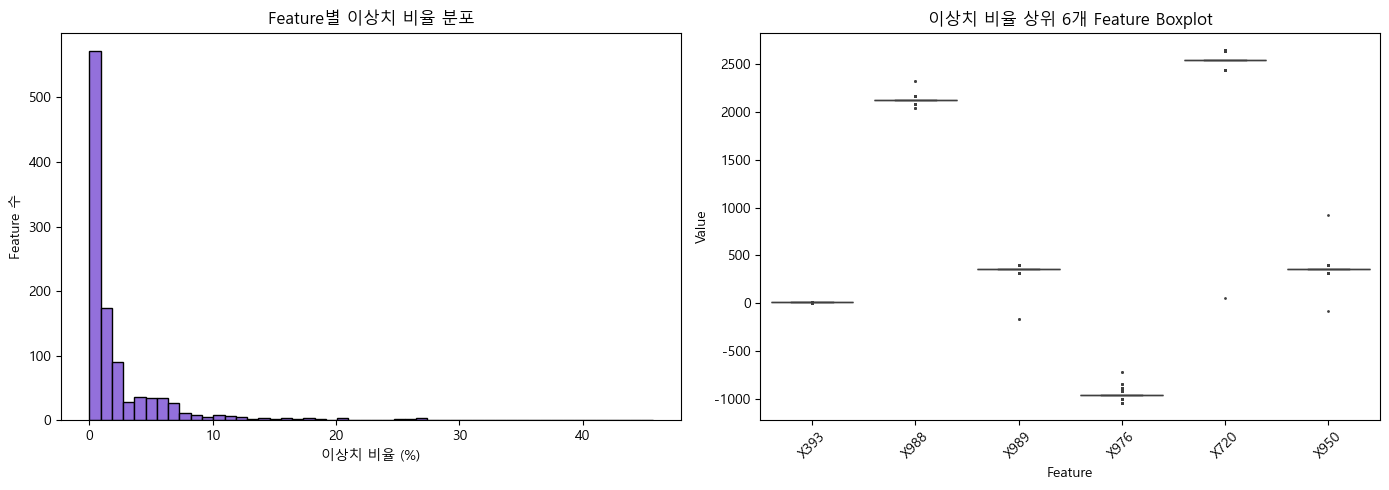

In [17]:
# IQR(사분위범위) 기준 이상치 비율 분석
# feature별 이상치 비율 분포 + 상위 6개 feature boxplot
out.plot_outlier_ratio(xs, feat_cols)

## 10. 범주형(이산형) Feature와 Target 관계

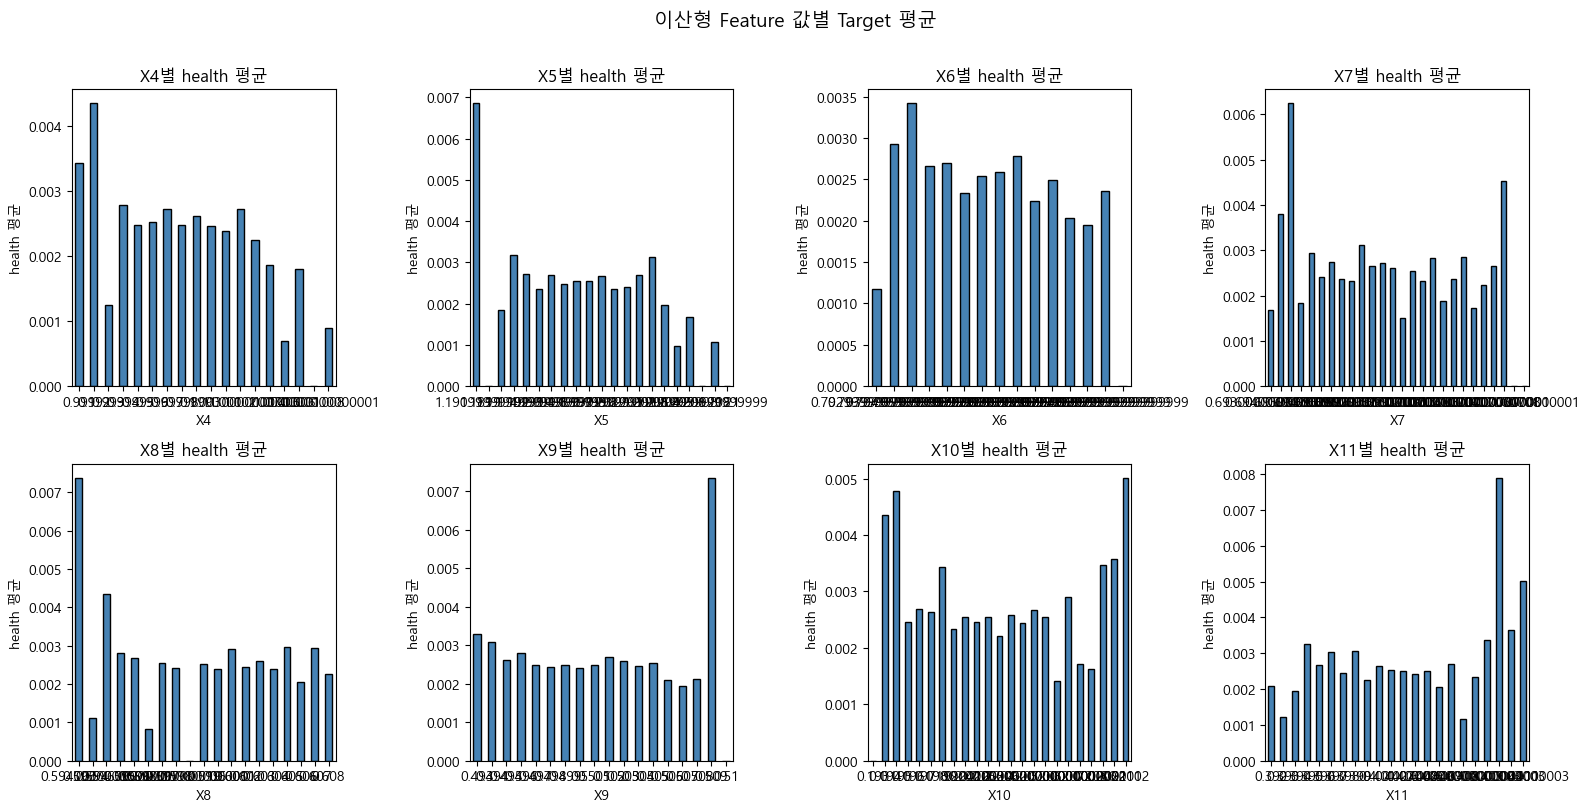

In [18]:
# 이산형 feature의 각 값(카테고리)별 target 평균 비교
# 특정 값일 때 health가 유의미하게 높아지는지 확인
rel.plot_discrete_vs_target(xs_dict, ys_train, discrete_feats)

## 11. 정규성 검정 및 스케일 분석

mean 범위:  [-2292.6725, 20201108.8805]
std 범위:   [0.0000, 10298.9925]
range 범위: [0.0000, 45839.0000]

왜도(skewness):
  |skew| > 2: 314개
  |skew| > 5: 175개


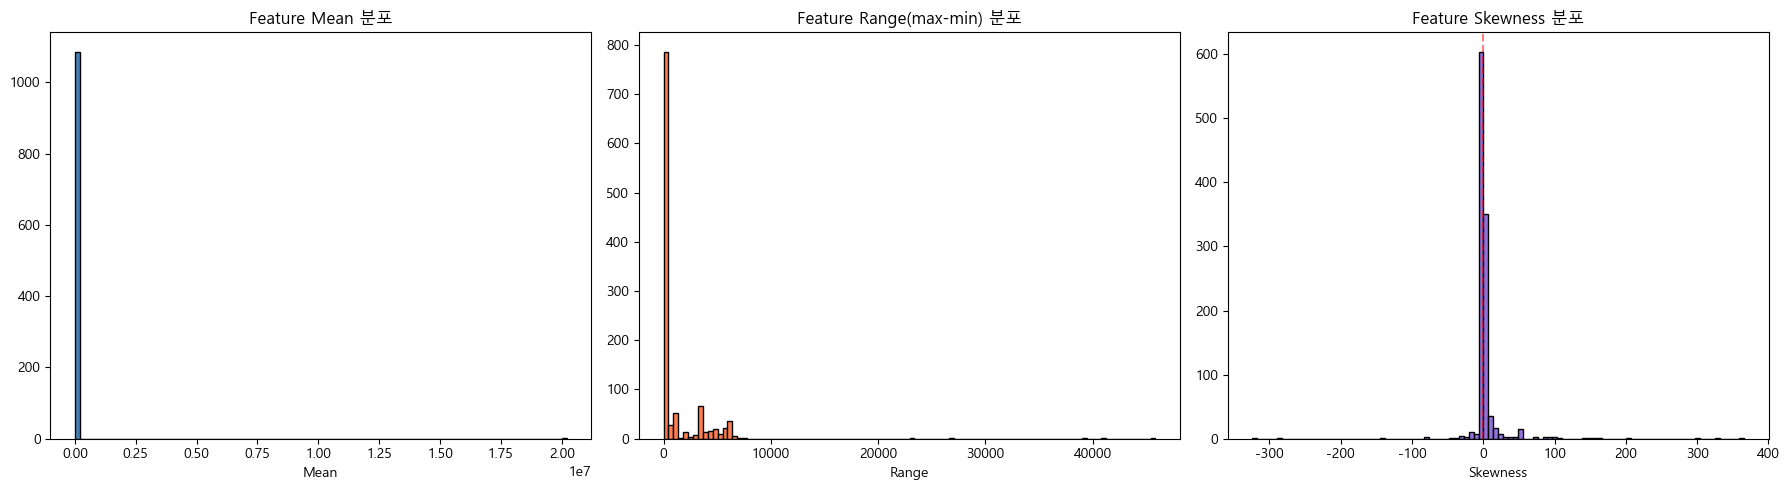

In [19]:
# feature들의 스케일 불균형 확인
# mean, range(max-min), skewness 분포 -> Standardization 필요성 판단
out.plot_scale_analysis(xs, feat_cols)

## 12. Wafer Map 불량 시각화
- run_wf_xy 파싱 → 작업번호, 웨이퍼번호, die 좌표 추출
- 불량률 높은 wafer 상위 N장 선별 → scatter plot
- 하늘색(정상) → 빨강(불량), 고정 크기

In [20]:
# run_wf_xy에서 wafer 좌표 파싱
# "작업번호_웨이퍼번호_X_Y" 형식 -> lot, wafer_no, die_x, die_y 컬럼 생성
xs_parsed = wm.parse_wafer_coords(xs)

파싱 완료: 174,980 dies
고유 lot 수: 28
고유 wafer 수: 432
die_x 범위: 12 ~ 66
die_y 범위: 11 ~ 32


In [21]:
# 불량률(health > 0 비율) 높은 wafer 상위 6장 선택
# 불량이 집중된 wafer를 골라서 시각화 대상으로 삼음
top_wafers = wm.select_top_wafers(xs_parsed, ys_train)


전체 wafer 수 (train): 432

불량률 상위 6장:
  wafer_id  total_dies  defect_dies  mean_health  defect_rate
 0000024_2         192          108     0.005136         56.2
0000024_13         224          124     0.004133         55.4
0000024_16         249          136     0.003779         54.6
0000024_25         220          120     0.004516         54.5
0000024_23         328          172     0.003913         52.4
0000005_18         269          141     0.004047         52.4


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


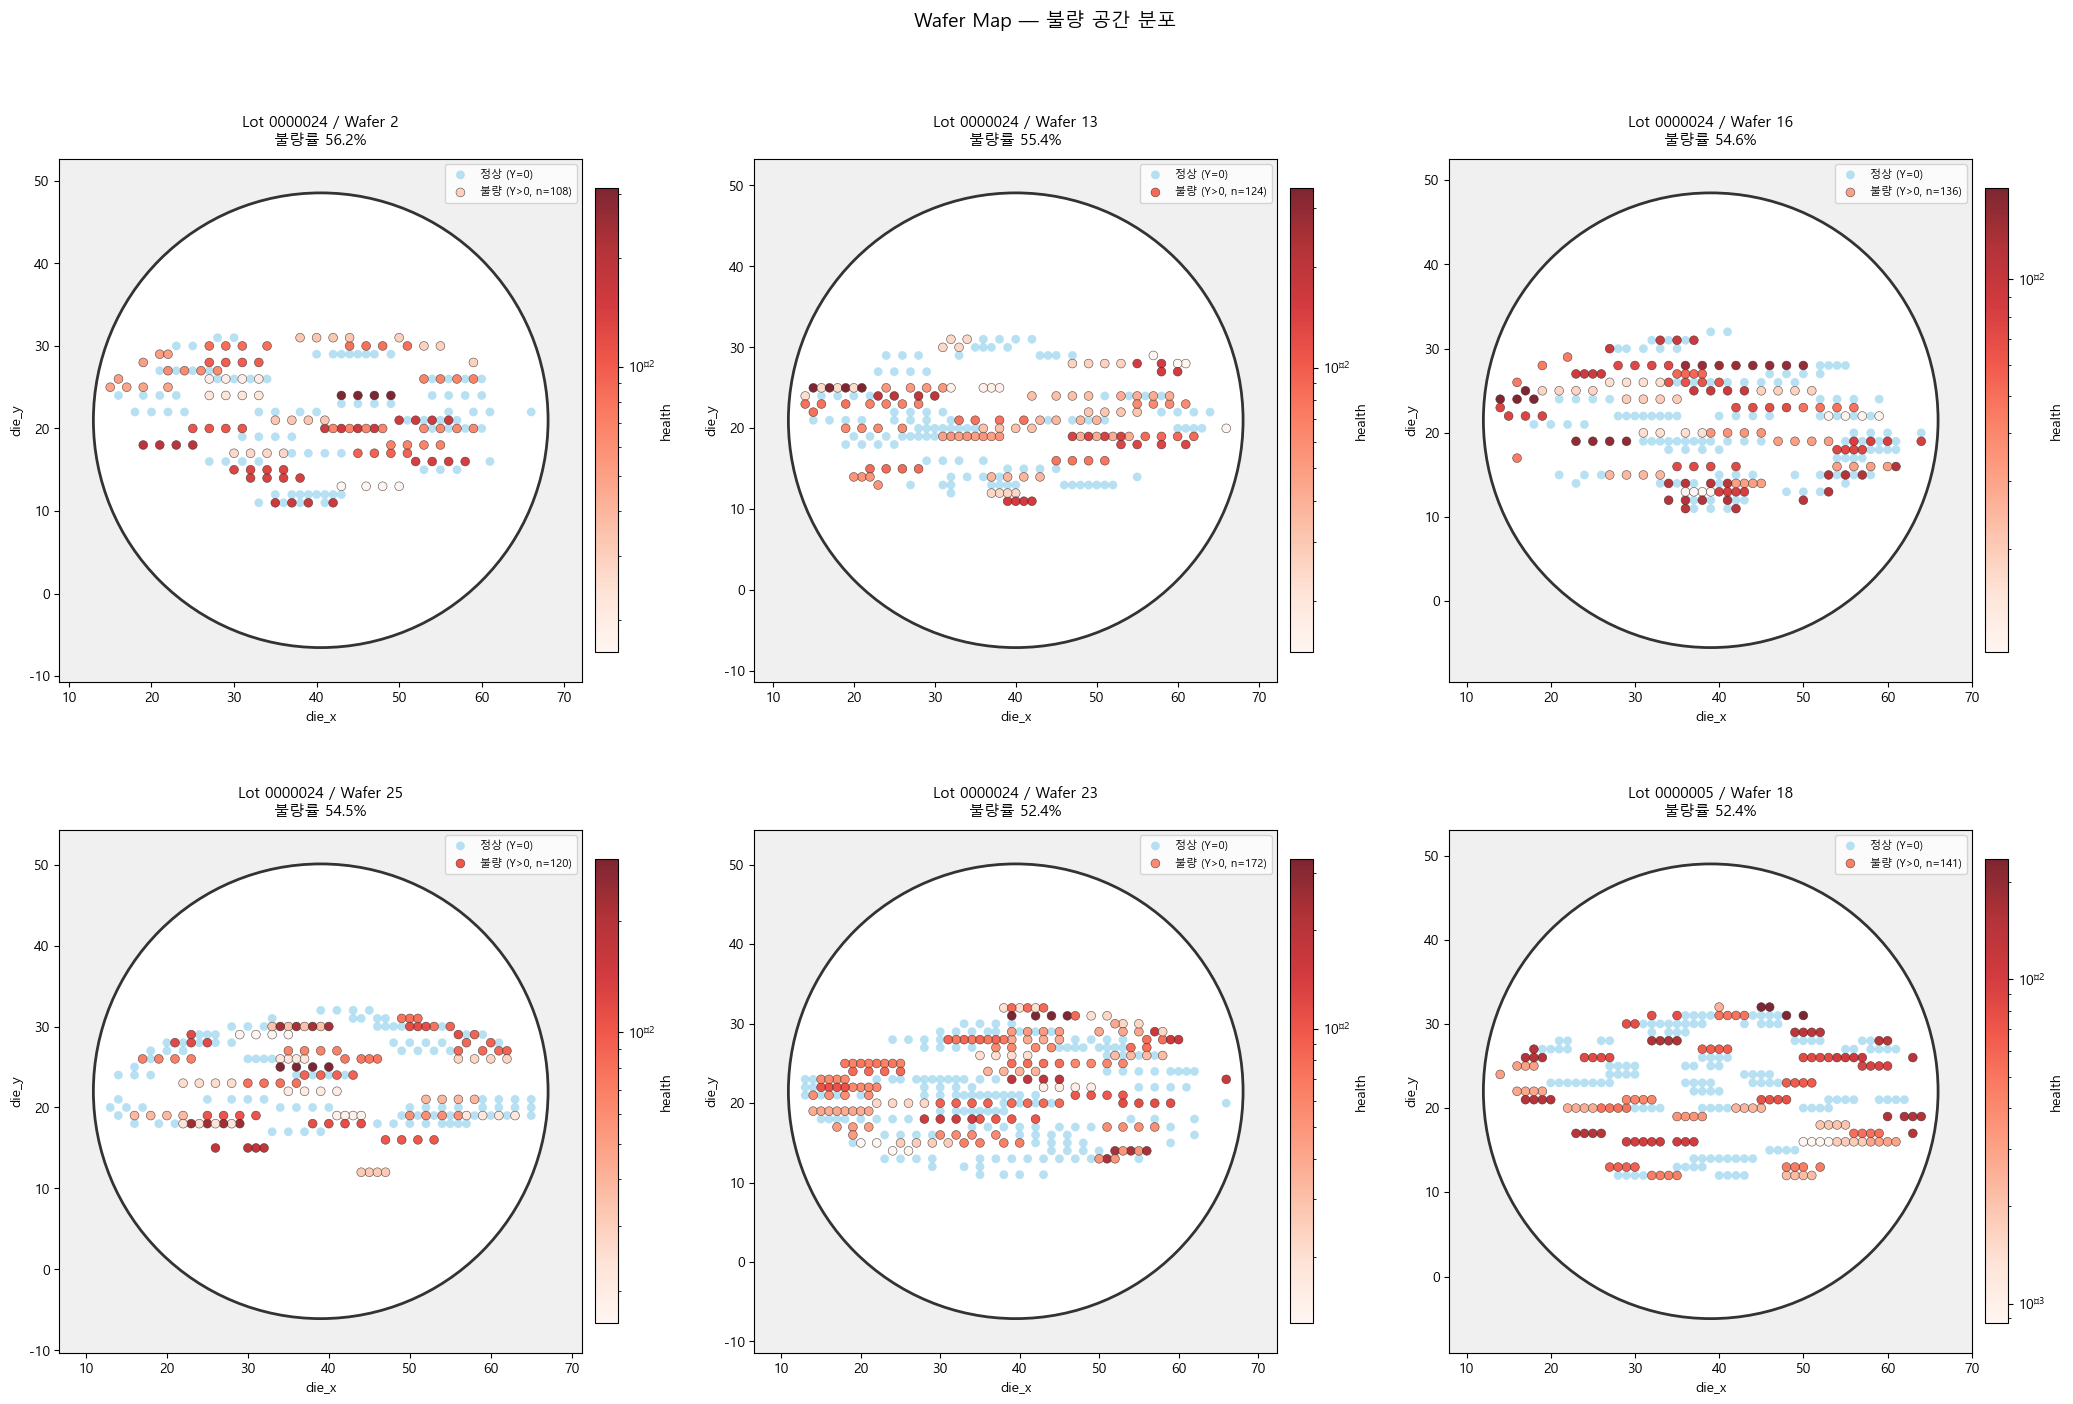

In [22]:
# 선택된 wafer들의 die 위치를 scatter plot으로 시각화
# 정상(Y=0): 하늘색, 불량(Y>0): 빨강 계열 (값 클수록 진한 빨강)
# 같은 unit의 4개 die는 동일 health 값이라 자연스럽게 같은 색
# 불량이 특정 영역(edge, center 등)에 집중되는지 공간 패턴 확인
wm.plot_wafer_map(xs_parsed, ys_train, top_wafers)